# PCA latent-axis exploration

PCA directions and explained variance for each category embedding space.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name == "step_4_clustering" else CWD

source_path = ROOT / "helpers" / "source_helpers.py"
exec(compile(source_path.read_text(encoding="utf-8"), str(source_path), "exec"), globals())

metadata, embeddings, resolved_embedding_dir = load_embeddings(ROOT)
print("Embedding source:", resolved_embedding_dir.relative_to(ROOT))
metadata.shape, embeddings.shape


Matplotlib is building the font cache; this may take a moment.


Embedding source: step_2_text_embeddings


((1689, 12), (1689, 768))

## PCA threshold table


In [2]:
pca_summary = pca_threshold_summary(ROOT)
save_pca_threshold_summary(ROOT)
save_table(pca_summary, "pca_thresholds", ROOT)
display(pca_summary)


,category,n_brands,pcs_for_50pct,pcs_for_70pct,pcs_for_80pct,pcs_for_90pct,pcs_for_95pct,pc1_variance,pc2_variance,pc10_cumulative
0,Clothes,746,8,21,35,68,106,0.152786,0.078895,0.556099
1,Shoes,316,7,17,27,48,73,0.184458,0.071388,0.586807
2,Bags,301,7,16,25,47,72,0.140466,0.093016,0.600840
3,Jewellery,326,7,16,26,49,76,0.148500,0.115607,0.606171


## Figure file


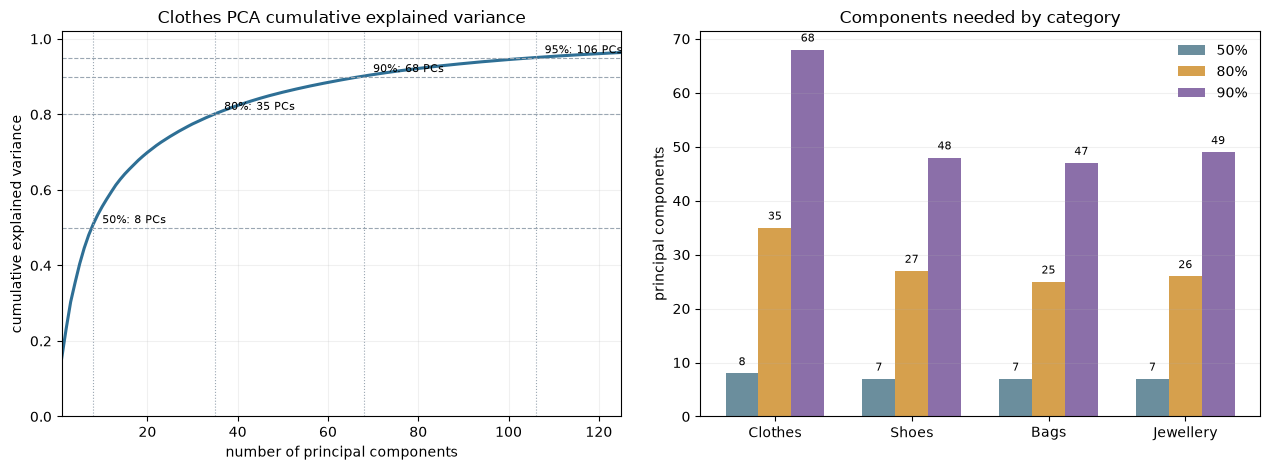

In [3]:
thresholds = [0.50, 0.80, 0.90, 0.95]
curves = {}
for category in CATEGORIES:
    X = embeddings[metadata["category"].eq(category).to_numpy()]
    pca = PCA(n_components=min(X.shape[0] - 1, X.shape[1]), random_state=42).fit(X)
    curves[category] = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
clothes_curve = curves["clothes"]
axes[0].plot(np.arange(1, len(clothes_curve) + 1), clothes_curve, color="#2E6F95", linewidth=2.2)
for threshold in thresholds:
    k = int(np.searchsorted(clothes_curve, threshold) + 1)
    axes[0].axhline(threshold, color="#9AA6B2", linestyle="--", linewidth=0.8)
    axes[0].axvline(k, color="#9AA6B2", linestyle=":", linewidth=0.8)
    axes[0].text(k + 2, threshold + 0.012, f"{int(threshold * 100)}%: {k} PCs", fontsize=8)
axes[0].set_xlim(1, 125)
axes[0].set_ylim(0, 1.02)
axes[0].set_title("Clothes PCA cumulative explained variance")
axes[0].set_xlabel("number of principal components")
axes[0].set_ylabel("cumulative explained variance")
axes[0].grid(alpha=0.18)

plot_summary = pca_summary.copy()
plot_summary["category_key"] = plot_summary["category"].str.lower()
x = np.arange(len(plot_summary))
width = 0.24
axes[1].bar(x - width, plot_summary["pcs_for_50pct"], width, label="50%", color="#6B8E9D")
axes[1].bar(x, plot_summary["pcs_for_80pct"], width, label="80%", color="#D6A04D")
axes[1].bar(x + width, plot_summary["pcs_for_90pct"], width, label="90%", color="#8B6FA9")
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_summary["category"])
axes[1].set_title("Components needed by category")
axes[1].set_ylabel("principal components")
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.18)
for i, row in enumerate(plot_summary.itertuples()):
    axes[1].text(i - width, row.pcs_for_50pct + 1.5, str(row.pcs_for_50pct), ha="center", fontsize=8)
    axes[1].text(i, row.pcs_for_80pct + 1.5, str(row.pcs_for_80pct), ha="center", fontsize=8)
    axes[1].text(i + width, row.pcs_for_90pct + 1.5, str(row.pcs_for_90pct), ha="center", fontsize=8)

plt.tight_layout()
for ext in ["pdf", "png"]:
    fig.savefig(thesis_figures_dir(ROOT) / f"latent_axis_pca_summary.{ext}", bbox_inches="tight", dpi=220)
plt.show()
